### 🤖 LLM and AI Agent Development Courses  
**✨ All courses available for just ₹399 INR / $9.99 USD ✨**

| Course | Description | Enroll |
|--------|-------------|---------|
| **🎯 Master OpenAI Agent Builder** | Build and deploy AI agents visually using OpenAI Agent Builder, ChatKit, RAG, Chatbot, AI Assistant with MCP, AWS, RDS MySQL | [Enroll Now](https://kgptalkie.com/agent-builder) |
| **🔥 MCP Mastery** | Build MCP servers & clients with Python, Streamlit, ChromaDB, LangChain, LangGraph agents, and Ollama integrations | [Enroll Now](https://kgptalkie.com/mcp) |
| **📊 Private Agentic RAG with LangChain** | Step-by-Step Guide to RAG with LangChain v1, LangGraph, and Ollama (Qwen3, Gemma3, DeepSeek-R1, LLAMA, FAISS) | [Enroll Now](https://kgptalkie.com/agentic-rag) |
| **🔧 Master LangGraph and LangChain** | Agentic RAG and Chatbot, AI Agent with LangChain v1, Qwen3, Gemma3, DeepSeek-R1, LLAMA 3.2, FAISS Vector Database | [Enroll Now](https://kgptalkie.com/langgraph) |
| **⚡ Master Langchain and Ollama** | Master Langchain v1, Local LLM Projects with Ollama, Qwen3, Gemma3, DeepSeek-R1, LLAMA 3.2, Complete Integration Guide | [Enroll Now](https://kgptalkie.com/langchain) |
| **🔬 Fine Tuning LLM** | Learn transformer architecture fundamentals and fine-tune LLMs with custom datasets | [Enroll Now](https://kgptalkie.com/fine-tuning-llm) |

---

### 🌐 Join the Community & Stay Connected

- 🔗 **Join the Discord Community:** https://discord.gg/RFjwbkNa  
- 📺 **Subscribe on YouTube (63K+ learners):** http://www.youtube.com/@KGPTalkie

---


## LangChain v1 Agents: Complete Guide

## Prerequisites

Make sure you have the required packages installed and Ollama running:

```bash
pip install -U langchain langchain-community langchain-core langgraph
pip install -U ddgs python-dotenv
```

Local LLM Serving with Ollama:
```bash
ollama pull qwen3
ollama pull gemma3
```

In [2]:
# pip install -U langchain langchain-community langchain-core langgraph
# pip install -U ddgs python-dotenv

---
## 1. Agent with Explicit Model Instance

Full control over model configuration by creating an explicit ChatOllama instance.

## Model Parameters Explained
- **temperature**: Controls randomness (0.0 = deterministic, 1.0 = very creative)
- **num_predict**: Maximum tokens to generate (similar to max_tokens in OpenAI)
- **top_k**: Number of highest probability tokens to consider
- **top_p**: Cumulative probability threshold for token selection
- **repeat_penalty**: Penalty for repeating tokens
- **num_ctx**: Context window size

In [3]:
from langchain_ollama import ChatOllama
from langchain.agents import create_agent
from langfuse.langchain import CallbackHandler
import tools

langfuce_trace = CallbackHandler()

In [4]:
system_prompt = """You are a helpful AI assistant. 
Use the available tools when needed to answer questions accurately.
If you need to search for information, use the web_search tool.
Always provide clear and concise answers.
"""

In [5]:
print(tools.web_search.invoke({"query": "What is Langchain?", "num_results": 1}))
# print(tools.web_search.invoke({"query": "Python programming", "num_results": 1}))

Search Results for 'What is Langchain?':


1. **LangChain Blog**
   1 hour ago · Explore tutorials, case studies, and technical insights on building AI agents with LangSmith, Deep Agents, LangGraph, and LangChain. Learn from experts.
   https://www.langchain.com/blog


### Your First Agent

In [6]:
model = ChatOllama(model="qwen3", base_url="http://localhost:11434")

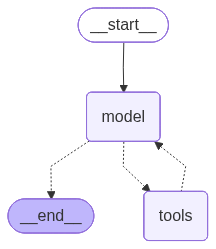

In [7]:
agent = create_agent(model=model, tools=[tools.web_search], system_prompt=system_prompt)
agent

In [8]:
result = agent.invoke({"messages": "What is the top 10 global news right now?"}, config={"callbacks": [langfuce_trace]})

In [9]:
result

{'messages': [HumanMessage(content='What is the top 10 global news right now?', additional_kwargs={}, response_metadata={}, id='477b126f-39c6-47b4-80be-306dc757437f'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3', 'created_at': '2026-05-29T12:31:36.234431949Z', 'done': True, 'done_reason': 'stop', 'total_duration': 82243619855, 'load_duration': 9891053319, 'prompt_eval_count': 247, 'prompt_eval_duration': 7338585457, 'eval_count': 470, 'eval_duration': 64816794464, 'logprobs': None, 'model_name': 'qwen3', 'model_provider': 'ollama'}, id='lc_run--019e73b6-b3e0-75e3-8e68-415f27bba1aa-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'top 10 global news', 'num_results': 10}, 'id': '8ed08b07-b7a4-496f-82f8-49361cfbea8f', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 247, 'output_tokens': 470, 'total_tokens': 717}),
  ToolMessage(content="Search Results for 'top 10 global news':\n\n\n1. **Iran US War | ARY News 3 PM

In [10]:
print(result['messages'])

[HumanMessage(content='What is the top 10 global news right now?', additional_kwargs={}, response_metadata={}, id='477b126f-39c6-47b4-80be-306dc757437f'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3', 'created_at': '2026-05-29T12:31:36.234431949Z', 'done': True, 'done_reason': 'stop', 'total_duration': 82243619855, 'load_duration': 9891053319, 'prompt_eval_count': 247, 'prompt_eval_duration': 7338585457, 'eval_count': 470, 'eval_duration': 64816794464, 'logprobs': None, 'model_name': 'qwen3', 'model_provider': 'ollama'}, id='lc_run--019e73b6-b3e0-75e3-8e68-415f27bba1aa-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'top 10 global news', 'num_results': 10}, 'id': '8ed08b07-b7a4-496f-82f8-49361cfbea8f', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 247, 'output_tokens': 470, 'total_tokens': 717}), ToolMessage(content="Search Results for 'top 10 global news':\n\n\n1. **Iran US War | ARY News 3 PM Headlines - 29 M

In [11]:
print(result['messages'][-1].content) # Access result from AIMessage class output

Here’s a summary of the top global news stories based on recent updates:

1. **Iran-US Conflict Escalates**  
   - **Tensions** between the U.S. and Iran continue with attacks on military facilities, raising fears of a renewed conflict. (Source: YouTube, 14 hours ago)  
   - **Ceasefire Concerns**: Analysts warn of a potential breakdown in ceasefire talks. (Source: YouTube, 14 hours ago)  

2. **Trump’s Role in Iran Negotiations**  
   - Former President Trump’s negotiation strategies are being discussed as a possible solution to the Iran crisis. (Source: *The Guardian*, 17 hours ago)  

3. **U.S.-Canada Relations Under Pressure**  
   - U.S. Secretary of State Antony Blinken (Carney) is actively engaging with Trump ahead of trade deal deadlines, highlighting ongoing diplomatic tensions. (Source: *NY Times*, 14 hours ago)  

4. **Deadly Heatwave in Western Europe**  
   - A severe heatwave is causing widespread disruption across Western Europe, with record temperatures and health emerg

In [12]:

result['messages'][-1].pretty_print()

================================== Ai Message ==================================

Here’s a summary of the top global news stories based on recent updates:

1. **Iran-US Conflict Escalates**  
   - **Tensions** between the U.S. and Iran continue with attacks on military facilities, raising fears of a renewed conflict. (Source: YouTube, 14 hours ago)  
   - **Ceasefire Concerns**: Analysts warn of a potential breakdown in ceasefire talks. (Source: YouTube, 14 hours ago)  

2. **Trump’s Role in Iran Negotiations**  
   - Former President Trump’s negotiation strategies are being discussed as a possible solution to the Iran crisis. (Source: *The Guardian*, 17 hours ago)  

3. **U.S.-Canada Relations Under Pressure**  
   - U.S. Secretary of State Antony Blinken (Carney) is actively engaging with Trump ahead of trade deal deadlines, highlighting ongoing diplomatic tensions. (Source: *NY Times*, 14 hours ago)  

4. **Deadly Heatwave in Western Europe**  
   - A severe heatwave is causing wide

In [13]:
result1 = agent.invoke(result, config={"callbacks": [langfuce_trace]})

In [14]:
result1

{'messages': [HumanMessage(content='What is the top 10 global news right now?', additional_kwargs={}, response_metadata={}, id='477b126f-39c6-47b4-80be-306dc757437f'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3', 'created_at': '2026-05-29T12:31:36.234431949Z', 'done': True, 'done_reason': 'stop', 'total_duration': 82243619855, 'load_duration': 9891053319, 'prompt_eval_count': 247, 'prompt_eval_duration': 7338585457, 'eval_count': 470, 'eval_duration': 64816794464, 'logprobs': None, 'model_name': 'qwen3', 'model_provider': 'ollama'}, id='lc_run--019e73b6-b3e0-75e3-8e68-415f27bba1aa-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'top 10 global news', 'num_results': 10}, 'id': '8ed08b07-b7a4-496f-82f8-49361cfbea8f', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 247, 'output_tokens': 470, 'total_tokens': 717}),
  ToolMessage(content="Search Results for 'top 10 global news':\n\n\n1. **Iran US War | ARY News 3 PM

### Experimenting with Different Settings

Let's compare different model configurations to see how they affect the output:

In [15]:
question = "What is the capital of France? Provide a brief explanation."

model1 = ChatOllama(model="qwen3", base_url="http://localhost:11434",
                    temperature=0,
                    top_p=1,
                    repeart_penalty=1.2,
                    num_predict=1000,
                    num_ctx=4096,
                    reasoning=True)

agent1 = create_agent(model=model1, tools=[tools.web_search], system_prompt=system_prompt)
result1 = agent1.invoke({"messages": question}, config={"callbacks": [langfuce_trace]})

In [16]:
result1

{'messages': [HumanMessage(content='What is the capital of France? Provide a brief explanation.', additional_kwargs={}, response_metadata={}, id='4b7fe6f9-d604-4306-9f3b-1d9477422f89'),
  AIMessage(content='The capital of France is **Paris**. Paris is not only the political and cultural heart of France but also a major global city known for its landmarks like the Eiffel Tower, Louvre Museum, and historic architecture. It serves as the seat of the French government and is a hub for art, fashion, and commerce.', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the capital of France and a brief explanation. Let me start by recalling what I know. France is a country in Europe, and I believe the capital is Paris. But wait, I should make sure this information is up-to-date. Maybe there\'s a possibility of a change, though that\'s unlikely. To confirm, I can use the web_search tool. Let me check the function parameters. The tool requires a query and num_results. The query

## 2. Dynamic Model Selection (Qwen3 → Gemma3)

Cost-optimization strategy where the agent automatically switches between models based on conversation complexity.

## Selection Logic
- **< 10 messages**: Use Qwen3 (fast, efficient)
- **≥ 10 messages**: Use Gemma3 (better reasoning, longer context)

## Real-World Applications
- Customer service bots (simple queries → Qwen3, complex issues → Gemma3)
- Research assistants (quick facts → Qwen3, analysis → Gemma3)

In [17]:
# Import required modules
from langchain_ollama import ChatOllama
from langchain.agents import create_agent, AgentState
from langgraph.runtime import Runtime
import tools

# Import the middleware decorator
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse


In [18]:
basic_model = ChatOllama(model="qwen3:4b", base_url="http://localhost:11434", num_predict=1000)
advanced_model = ChatOllama(model="llama3.2", base_url="http://localhost:11434", num_predict=1000)

@wrap_model_call
def dynamic_model_selection(request: ModelRequest, handler) -> ModelResponse:
    message_count = len(request.state["messages"])
    if message_count<3:
        print(f"Using Qwen3 for {message_count} messages")
        request.model = basic_model
    else:
        print(f"Using llama3.2 for {message_count} messages")
        request.model = advanced_model

    return handler(request)

In [19]:
agent = create_agent(model=basic_model,
                     tools = [tools.web_search],
                     system_prompt=system_prompt,
                     middleware=[dynamic_model_selection])

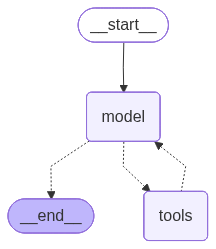

In [20]:
agent

In [ ]:
def get_agent_output(messages:list):
    messages = {'messages': messages} # dict
    result = agent.invoke(messages, config={"callbacks": [langfuce_trace]})

    return result

In [22]:
messages = ["How are you?", "What's the weather in Mumbai today?,", "Explain machine learning"]
result = get_agent_output(messages)

Using llama3.2 for 3 messages


C:\Users\Admin\AppData\Local\Temp\ipykernel_21312\2338425097.py:12: DeprecationWarning: Direct attribute assignment to ModelRequest.model is deprecated. Use request.override(model=...) instead to create a new request with the modified attribute.
  request.model = advanced_model


Using llama3.2 for 6 messages


C:\Users\Admin\AppData\Local\Temp\ipykernel_21312\2338425097.py:12: DeprecationWarning: Direct attribute assignment to ModelRequest.model is deprecated. Use request.override(model=...) instead to create a new request with the modified attribute.
  request.model = advanced_model


In [23]:
result

{'messages': [HumanMessage(content='How are you?', additional_kwargs={}, response_metadata={}, id='6e52c86b-2d11-4586-83d3-a15fac2f58b6'),
  HumanMessage(content="What's the weather in Mumbai today?,", additional_kwargs={}, response_metadata={}, id='dca780c5-cd02-4f0e-969b-540d13ea257e'),
  HumanMessage(content='Explain machine learning', additional_kwargs={}, response_metadata={}, id='3916b4e9-25cd-42a4-b10d-15ce29ead579'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-05-29T12:37:37.743221718Z', 'done': True, 'done_reason': 'stop', 'total_duration': 17987549643, 'load_duration': 11884472123, 'prompt_eval_count': 263, 'prompt_eval_duration': 3007154998, 'eval_count': 52, 'eval_duration': 3049010928, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--019e73bd-330a-7792-a6b7-402650ed9aa9-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'Mumbai weather today', 'num_results': 10}, 'id': '

### Streaming Agent Responses
#### Stream Modes
- "values": Get complete state at each step
- "updates": Get only the changes/updates
- "messages": Get only message updates

In [24]:
messages

['How are you?',
 "What's the weather in Mumbai today?,",
 'Explain machine learning']

In [25]:
for chunk in agent.stream({"messages": messages}, stream_mode="values"):
    print(chunk['messages'][-1].content, end='', flush=True)

    print("\n\n------")

Explain machine learning

------
Using llama3.2 for 3 messages


C:\Users\Admin\AppData\Local\Temp\ipykernel_21312\2338425097.py:12: DeprecationWarning: Direct attribute assignment to ModelRequest.model is deprecated. Use request.override(model=...) instead to create a new request with the modified attribute.
  request.model = advanced_model




------
Search Results for 'machine learning explanation':


1. **Large language model - Wikipedia**
   14 hours ago - As machine learning algorithms process numbers rather than text, the text must be converted to numbers. In the first step, a vocabulary is decided upon, then integer indices are arbitrarily but uniquely assigned to each vocabulary entry, and finally, an embedding is associated with the integer ...
   https://en.wikipedia.org/wiki/Large_language_model

2. **What Is Machine Learning? How It Works, Types & Real-World Uses (2026) - Memeburn**
   13 hours ago - Machine learning is a branch of artificial intelligence in which systems learn from data and improve over time, without being explicitly programmed to do so. In traditional programming, developers write specific rules that the computer follows.
   https://memeburn.com/what-is-machine-learning/

3. **What is Artificial Intelligence (AI)? | Google Cloud**
   1 day ago - As mentioned earlier, AI isn't ... Machine Learn

C:\Users\Admin\AppData\Local\Temp\ipykernel_21312\2338425097.py:12: DeprecationWarning: Direct attribute assignment to ModelRequest.model is deprecated. Use request.override(model=...) instead to create a new request with the modified attribute.
  request.model = advanced_model


Here are the answers to your questions:

**How are you?**
I'm doing well, thank you for asking! I'm a helpful AI assistant, and I'm here to provide information and assist with tasks to the best of my abilities.

**What's the weather in Mumbai today?**
According to the current weather forecast, there is scattered rain over Maharashtra, including Mumbai. The temperature is expected to be around 31°C, with a low of 30°C expected at night. You can check the latest weather updates on websites like Weather.com, AccuWeather, or India Meteorological Department (IMD) for more information.

**Explain machine learning**
Machine learning is a branch of artificial intelligence in which systems learn from data and improve over time, without being explicitly programmed to do so. It's a type of AI that enables computers to analyze large amounts of data, identify patterns, and make predictions or decisions without human intervention. Machine learning algorithms can be trained on various types of data, 

In [26]:
for chunk in agent.stream(
    {"messages": messages},
    config={"callbacks": [langfuce_trace]},
    stream_mode="updates",
):
    # print(chunk, end='', flush=True)
    if 'model' in chunk:
        chunk['model']['messages'][-1].pretty_print()
    if 'tools' in chunk:
        chunk['tools']['messages'][-1].pretty_print()
    else:
        print(chunk)
    print("\n\n------")

Using llama3.2 for 3 messages


C:\Users\Admin\AppData\Local\Temp\ipykernel_21312\2338425097.py:12: DeprecationWarning: Direct attribute assignment to ModelRequest.model is deprecated. Use request.override(model=...) instead to create a new request with the modified attribute.
  request.model = advanced_model


================================== Ai Message ==================================
Tool Calls:
  web_search (5206608a-40e2-4060-ac7c-55a4497bbb40)
 Call ID: 5206608a-40e2-4060-ac7c-55a4497bbb40
  Args:
    query: Mumbai weather today
    num_results: 10
  web_search (d6d6ba26-0ec2-4e23-bc4e-44e9fd3c40f6)
 Call ID: d6d6ba26-0ec2-4e23-bc4e-44e9fd3c40f6
  Args:
    query: machine learning explanation
    num_results: 5
  web_search (12364e88-2ee4-46c4-9ef4-93f2b57b3997)
 Call ID: 12364e88-2ee4-46c4-9ef4-93f2b57b3997
  Args:
    num_results: 1
    query: How are you?
{'model': {'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-05-29T12:39:19.976640715Z', 'done': True, 'done_reason': 'stop', 'total_duration': 7064077397, 'load_duration': 303752837, 'prompt_eval_count': 263, 'prompt_eval_duration': 1934162845, 'eval_count': 79, 'eval_duration': 4760107656, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'},

C:\Users\Admin\AppData\Local\Temp\ipykernel_21312\2338425097.py:12: DeprecationWarning: Direct attribute assignment to ModelRequest.model is deprecated. Use request.override(model=...) instead to create a new request with the modified attribute.
  request.model = advanced_model


================================== Ai Message ==================================

Here are the answers to your questions:

**How are you?**
I am functioning properly and ready to assist you with any questions or information you may need.

**What's the weather in Mumbai today?**

According to the latest weather forecasts, it is expected to be clear sky with few clouds in Mumbai today. The maximum temperature is expected to reach 36 degree Celsius, while the minimum temperature will stay at 28 degrees Celsius.

**Explain machine learning**

Machine learning is a type of artificial intelligence that enables computers to learn and improve their performance on a task without being explicitly programmed for it. It involves training algorithms on large datasets, which allows them to identify patterns and make predictions or decisions based on new, unseen data. Machine learning has many applications in areas such as image recognition, natural language processing, and predictive analytics.
{'mo